h = 0.01
eigenvalue magnitudes: [1.00005 1.00005]
Solution may not be Entirely Stable ;)

h = 0.1
eigenvalue magnitudes: [1.00498756 1.00498756]
Solution may not be Entirely Stable ;)

h = 0.5
eigenvalue magnitudes: [1.11803399 1.11803399]
Solution may not be Entirely Stable ;)

h = 1.0
eigenvalue magnitudes: [1.41421356 1.41421356]
Solution may not be Entirely Stable ;)



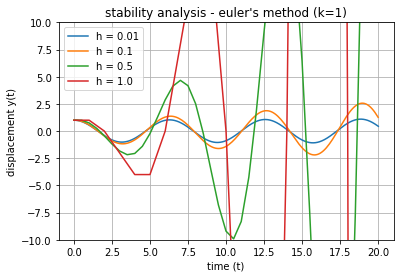

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# parameters
k = 1.0
h_values = [0.01, 0.1, 0.5, 1.0]
t_start = 0
t_end = 20
y_0 = 1.0
v_0 = 0.0

# euler's method
def euler_method(h, k, t_start, t_end, y_0, v_0):
    t = np.arange(t_start, t_end + h, h)
    y = np.zeros(len(t))
    v = np.zeros(len(t))

    y[0] = y_0
    v[0] = v_0

    for i in range(1, len(t)):
        y_n = y[i - 1]
        v_n = v[i - 1]

        y[i] = y_n + h * v_n
        v[i] = v_n + h * (-k * y_n)

    return t, y

# loop through each step size
for h in h_values:

    # build coefficient matrix
    A = np.array([[1, h], [-h * k, 1]])

    # compute eigenvalues
    eigenvalues = np.linalg.eigvals(A)

    # check if eigenvalue magnitude is greater than 1
    max_eig = np.max(np.abs(eigenvalues))

    # printing
    print(f"h = {h}")
    print(f"eigenvalue magnitudes: {np.abs(eigenvalues)}")

    if max_eig < 1:
        print("Solution is Stable")
    else:
        print("Solution may not be Entirely Stable ;)\n")

    t, y = euler_method(h, k, t_start, t_end, y_0, v_0)
    plt.plot(t, y, label=f'h = {h}')

# plotting
plt.title('stability analysis - euler\'s method (k=1)')
plt.xlabel('time (t)')
plt.ylabel('displacement y(t)')
plt.ylim(-10, 10)
plt.legend()
plt.grid(True)
plt.show()